In [4]:
import arviz as az
import numpy as np
import pandas as pd
#import argparse
import sys
import os

import pickle

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.colors as mcolors

In [6]:
cd ../

In [7]:
sys.path.insert(0, './src/')

In [8]:
from plot.odds_ratios import *

In [9]:

idata = az.from_netcdf('./idata/uk/child_cond_on_pre_and_post.nc')

with open('./dat/dat_for_inference/uk/var_mappings_child_cond_on_pre_and_post.p', 'rb') as f:
    var_mappings = pickle.load(f)
with open('./dat/dat_for_inference/uk/data_dict_child_cond_on_pre_and_post.p', 'rb') as f:
    data_dict = pickle.load(f)
survey = pd.read_csv('./dat/dat_for_inference/uk/survey_child_cond_on_pre_and_post.tsv', sep = '\t', index_col = 0)

num_samples = idata.posterior.chain.size * idata.posterior.draw.size

In [10]:
alpha_violin_plot_soc = 0.7
alpha_soc_backgound = 0.45

In [11]:
rename_mapping_for_plot = {}

recode_mapping_reverse = var_mappings['recode_mapping_reverse'].copy()

recode_mapping_for_plot = recode_mapping_reverse.copy()

value_mapping = {}

value_mapping['DIS'] = {
    'Not disabled under the Equality Act': 'Not disabled',
    
    'Disabled under the Equality Act: Day-to-day activities limited a little': 'Disabled:\nlimited a little',
    
    'Disabled under the Equality Act: Day-to-day activities limited a lot': 'Disabled:\nlimited a lot'
}

value_mapping['EMP'] = {
    'Student' : 'Student',
    'Economically inactive: Long-term sick or disabled': 'Long-term sick',
    'Economically inactive: Other': 'Inactive other',
    'Economically inactive: Looking after home or family': 'Looking after home',
    'Working part or full-time (including self-employed, excluding students)': 'Working',
    'Economically active (excluding full-time students): Unemployed: Seeking work or waiting to start a job already obtained: Available to start working within 2 weeks': 'Seeking work',
    'Economically inactive: Retired': 'Retired'
}

value_mapping['LAN'] = {'English (English or Welsh in Wales)' : 'English', 'Other' : 'Other', 'Polish' : 'Polish'}

for _var, _mapping in value_mapping.items():
    new_dict = recode_mapping_for_plot[_var].copy()
    new_dict = { k : _mapping[v] for k,v in new_dict.items() }
    recode_mapping_for_plot[_var] = new_dict.copy()

for k in recode_mapping_for_plot:
    rename_mapping_for_plot[k] = { v : recode_mapping_for_plot[k][i] for i,v in recode_mapping_reverse[k].items()}


survey_for_plot = survey.copy()

for k,d in rename_mapping_for_plot.items():
    if k in survey_for_plot.columns:
        survey_for_plot[k] = survey_for_plot[k].map(d)

survey_for_plot['Marginal'] = 'marginal'

recode_mapping_for_plot['Marginal'] = {0 : 'marginal'}
rename_mapping_for_plot['Marginal'] = {'marginal' : 'marginal'}

soc_dems = ['AGE', 'SEX', 'EDU', 'REL', 'ETH', 'LAN', 'MIG', 'BUK', 'YUK', 'HEA', 'SCH', 'DIS', 'ENP', 'EMP']

In [12]:
def compute_y_prob_and_net_change_pre_and_post(idata, survey_for_plot, var_list, warnings_option='ignore', N_dep = 4, treat_group = ''):
    import numpy as np
    import pandas as pd
    import warnings
    if (treat_group is None) or (treat_group in ['','average_post']):
        var_ext = ''
        y_log_prob_child_values = idata.posterior['y_log_prob_child'].values
        idata_shape = y_log_prob_child_values.shape
        y_log_prob_post_values = idata.posterior['y_log_prob_post'].values
    else:
        y_log_prob_child_values = idata.posterior['y_log_prob_child_treat'].values[:,:,:,:,:,:,treat_group]
        idata_shape = y_log_prob_child_values.shape
        y_log_prob_post_values = idata.posterior['y_log_prob_post_treat'].values[:,:,:,:,:,treat_group]
    
    warnings.simplefilter(action=warnings_option, category=pd.errors.PerformanceWarning)
    num_samples = idata.posterior.chain.size * idata.posterior.draw.size

    y_prob_pre_full = np.exp(idata.posterior['y_log_prob_pre'].values.reshape( num_samples,idata_shape[2],idata_shape[3] ) ) #.mean(axis = 1)
    y_prob_post_cond_on_pre_full = np.exp(y_log_prob_post_values.reshape( num_samples,idata_shape[2],idata_shape[3], idata_shape[4] ) ) #.mean(axis = 1)
    
    y_prob_pre = y_prob_pre_full.mean(axis = 1)
    y_prob_post_cond_on_pre = y_prob_post_cond_on_pre_full.mean(axis = 1)
    
    y_prob_child_cond_on_pre_post_full = np.exp(y_log_prob_child_values.reshape( num_samples,idata_shape[2],idata_shape[3],idata_shape[4], idata_shape[5]) )
    
    y_prob_post_full = np.zeros(y_prob_post_cond_on_pre_full.shape[:-1])
    for i in range(N_dep):
        y_prob_post_full += y_prob_post_cond_on_pre_full[:,:,i,:] * y_prob_pre_full[:,:,i][:,:,None]
    
    y_prob_post = y_prob_post_full.mean(axis = 1)
    
    
    y_prob_pre_post_full = y_prob_post_cond_on_pre_full * y_prob_pre_full[:,:,:,None]
    y_prob_pre_cond_on_post_full = y_prob_pre_post_full / y_prob_post_full[:,:,None,:] 
    
    y_prob_child_cond_on_pre_full = np.zeros( y_prob_child_cond_on_pre_post_full.shape[:-1] )
    y_prob_child_cond_on_post_full = np.zeros( y_prob_child_cond_on_pre_post_full.shape[:-1] )
    
    for i in range(N_dep):
        y_prob_child_cond_on_pre_full += y_prob_child_cond_on_pre_post_full[:,:,:,i,:] * y_prob_post_cond_on_pre_full[:,:,:,i][:,:,:,None]
        y_prob_child_cond_on_post_full += y_prob_child_cond_on_pre_post_full[:,:,i,:,:] * y_prob_pre_cond_on_post_full[:,:,i,:][:,:,:,None]

    y_prob_child_cond_on_pre = y_prob_child_cond_on_pre_full.mean(axis = 1)
    y_prob_child_cond_on_post = y_prob_child_cond_on_post_full.mean(axis = 1 )
    y_prob_child_cond_on_pre_post = y_prob_child_cond_on_pre_post_full.mean(axis = 1)

    y_prob_pre_post = y_prob_pre_post_full.mean(axis = 1)
    #####################
    
    ###
    
    y_child_increase_cond_on_post = np.zeros( y_prob_child_cond_on_post_full.shape[:3] )
    y_child_decrease_cond_on_post = np.zeros( y_prob_child_cond_on_post_full.shape[:3] )
    for i in range(4):
        y_child_increase_cond_on_post[:, :, i] = np.sum(y_prob_child_cond_on_post_full[:, :, i, i+1:], axis=-1)
        y_child_decrease_cond_on_post[:, :, i] = np.sum(y_prob_child_cond_on_post_full[:, :, i, :i], axis=-1)
    
    y_child_increase_post  = np.zeros( y_prob_child_cond_on_post_full.shape[:2] )
    y_child_decrease_post  = np.zeros( y_prob_child_cond_on_post_full.shape[:2] )
    
    for i in range(4):
        y_child_increase_post  += y_child_increase_cond_on_post[:,:,i] * y_prob_post_full[:,:,i]
        y_child_decrease_post += y_child_decrease_cond_on_post[:,:,i] * y_prob_post_full[:,:,i]
    
    y_child_net_change_post = y_child_increase_post - y_child_decrease_post
    
    ###
    
    y_child_increase_cond_on_pre = np.zeros( y_prob_child_cond_on_pre_full.shape[:3] )
    y_child_decrease_cond_on_pre = np.zeros( y_prob_child_cond_on_pre_full.shape[:3] )
    for i in range(4):
        y_child_increase_cond_on_pre[:, :, i] = np.sum(y_prob_child_cond_on_pre_full[:, :, i, i+1:], axis=-1)
        y_child_decrease_cond_on_pre[:, :, i] = np.sum(y_prob_child_cond_on_pre_full[:, :, i, :i], axis=-1)
    
    y_child_increase_pre  = np.zeros( y_prob_child_cond_on_pre_full.shape[:2] )
    y_child_decrease_pre  = np.zeros( y_prob_child_cond_on_pre_full.shape[:2] )
    
    for i in range(4):
        y_child_increase_pre  += y_child_increase_cond_on_pre[:,:,i] * y_prob_pre_full[:,:,i]
        y_child_decrease_pre += y_child_decrease_cond_on_pre[:,:,i] * y_prob_pre_full[:,:,i]
    
    y_child_net_change_pre = y_child_increase_pre - y_child_decrease_pre
    
    
    import warnings
    
    warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
    
    survey_for_soc_marginals_with_net_change_pre = survey_for_plot.copy()
    survey_for_soc_marginals_with_net_change_post = survey_for_plot.copy()
    y_child_net_change_pre_T = y_child_net_change_pre.transpose(1,0)
    y_child_net_change_post_T = y_child_net_change_post.transpose(1,0)
    prob_cols_net_change = [f'p_{s}' for s in range(num_samples)]
    survey_for_soc_marginals_with_net_change_pre[ prob_cols_net_change ] = y_child_net_change_pre_T[:,:]
    survey_for_soc_marginals_with_net_change_post[ prob_cols_net_change ] = y_child_net_change_post_T[:,:]
    
    net_change_dict_pre = {}
    net_change_dict_post = {}
    
    for var in var_list:
        avg_df_pre = survey_for_soc_marginals_with_net_change_pre.groupby(var)[prob_cols_net_change].mean() # .reset_index()
        avg_df_post = survey_for_soc_marginals_with_net_change_post.groupby(var)[prob_cols_net_change].mean()
        net_change_dict_pre[var] = avg_df_pre.copy()
        net_change_dict_post[var] = avg_df_post.copy()

    return {'y_prob_child_cond_on_pre' : y_prob_child_cond_on_pre, 'y_prob_child_cond_on_post' : y_prob_child_cond_on_post,
            'y_prob_child_cond_on_pre_post' : y_prob_child_cond_on_pre_post, 'y_prob_pre_post' : y_prob_pre_post,
           'net_change_dict_pre' : net_change_dict_pre, 'net_change_dict_post' : net_change_dict_post, } 

In [13]:
var_list_for_plot = ['AGE',
     'SEX',
     'EDU',
     'REL',
     'ETH',
     'LAN',
     'MIG',
     'BUK',
     #'YUK',
     'HEA',
     #'SCH',
     'DIS',
     #'ENP',
     'EMP'] + ['X1_relationship_ch_i','X1_sex_ch_i', 'X1_permission_ch_i'] + ['Marginal']
results_dict = {}
for treat in ['average_post'] + [0,1,2,3,4,5,6]:
    print(treat)
    results_dict[treat] = compute_y_prob_and_net_change_pre_and_post(idata, survey_for_plot, var_list = var_list_for_plot, treat_group = treat)

average_post
0
1
2
3
4
5
6


In [14]:
var_list_for_plot = ['AGE',
     'SEX',
     'EDU',
     'REL',
     'ETH',
     'LAN',
     'MIG',
     'BUK',
     #'YUK',
     'HEA',
     #'SCH',
     'DIS',
     #'ENP',
     'EMP'] + ['X1_relationship_ch_i','X1_sex_ch_i', 'X1_permission_ch_i'] + ['Marginal']
results = compute_y_prob_and_net_change_pre_and_post(idata, survey_for_plot, var_list = var_list_for_plot)
net_change_dict_pre = results['net_change_dict_pre']
net_change_dict_post = results['net_change_dict_post']
y_prob_child_cond_on_pre_post = results['y_prob_child_cond_on_pre_post']
y_prob_child_cond_on_pre = results['y_prob_child_cond_on_pre']
y_prob_child_cond_on_post = results['y_prob_child_cond_on_post']
y_prob_pre_post = results['y_prob_pre_post']

In [15]:
results['net_change_dict_pre']['Marginal'].mean(axis = 1), results['net_change_dict_post']['Marginal'].mean(axis = 1)

(Marginal
 marginal    0.012389
 dtype: float64,
 Marginal
 marginal    0.058103
 dtype: float64)

In [16]:
desired_order = [
    'AGE', 'EDU', 'EMP', 'DIS', 'HEA', 'REL', 'BUK', 'ETH', 'LAN', 'MIG', 
    'SEX', 'X1_relationship_ch_i', 'X1_sex_ch_i', 'X1_permission_ch_i', 'Marginal',
]

categories_dict = {var : list( rename_mapping_for_plot[var].values() ) for var in results_dict['average_post']['net_change_dict_post'] } # {'no_post_strat_var' : ['Marginal']}
categories_dict = {var : list( np.sort(categories) ) for var, categories in categories_dict.items() }

categories_dict  = {key: categories_dict[key] for key in desired_order}

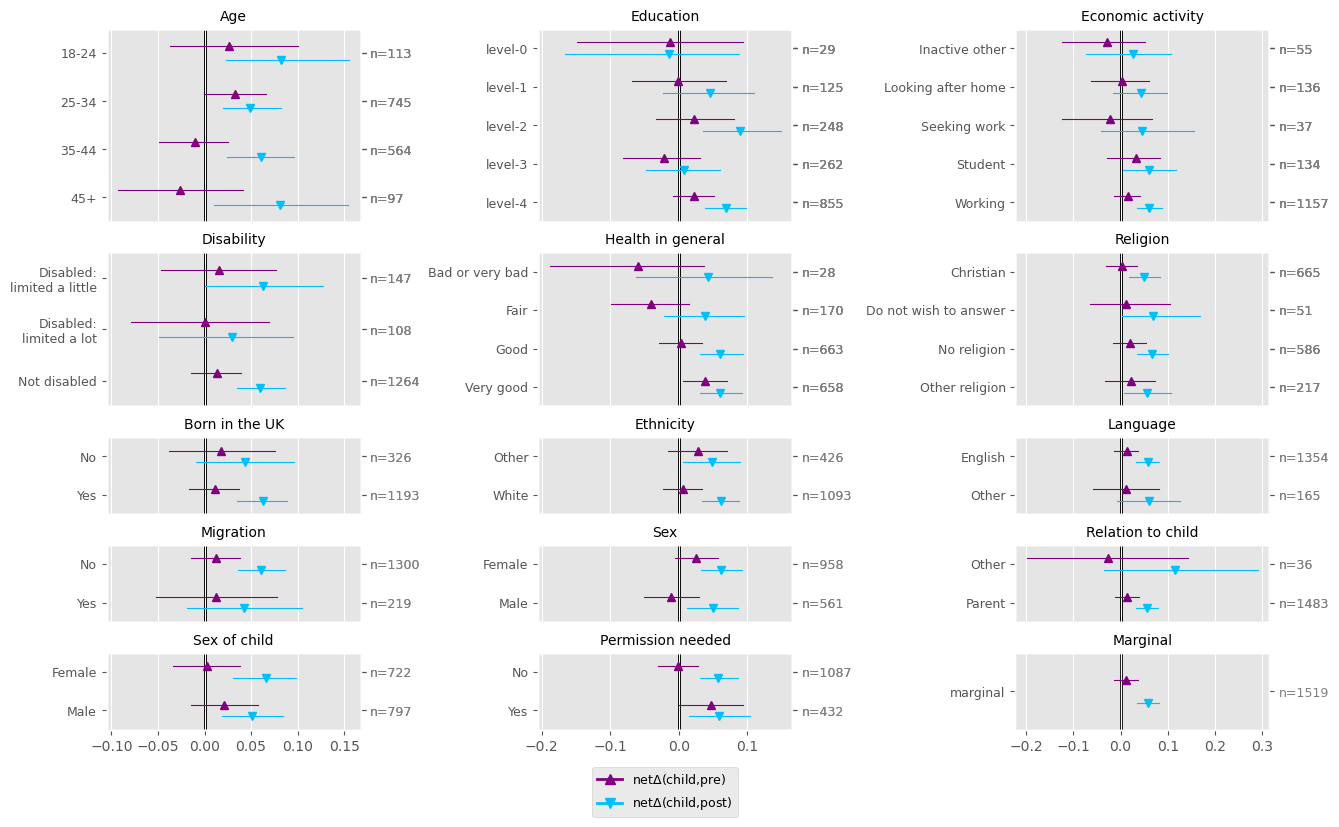

In [17]:
_results_dict = results_dict['average_post']#[3] # ['average_post'] + [0,1,2,3,4,5,6]

from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec

title_var_names = {'AGE': 'Age',
 'SEX': 'Sex',
 'EDU': 'Education',
 'REL': 'Religion',
 'ETH': 'Ethnicity',
 'LAN': 'Language',
 'HHLAN': 'Household language English',
 'MIG': 'Migration',
 'BUK': 'Born in the UK',
 'YUK': 'Year of arrival in UK',
 'HEA': 'Health in general',#'Fair',
 'SCH': 'No',
 'DIS': 'Disability',
 'ENP': 'Enlgish proficieny',
 'EMP': 'Economic activity',
 'X1_relationship_ch_i' : 'Relation to child',
 'X1_sex_ch_i' : 'Sex of child',
 'X1_permission_ch_i' : 'Permission needed',
 'Marginal' : 'Marginal'}

_y_offset = 0.5

plt.style.use('ggplot')

fig_num_rows = 5
fig_num_cols = 3

fig = plt.figure(figsize=(15, 10) ) # , constrained_layout = True)
gs = GridSpec(fig_num_rows + 1, fig_num_cols + 2, 
              figure=fig, wspace=0.55, hspace=0.3,  
              height_ratios=[5, 4, 2, 2, 2, 1], 
              width_ratios=[1, 0.0, 1, 0.18, 1]) 

axes = []
for i in range(fig_num_rows):
    row_axes = []
    for j in range(fig_num_cols):
        j_gs = 2 * j  
        if i == 0:
            ax = fig.add_subplot(gs[i, j_gs])
        else:
            ax = fig.add_subplot(gs[i, j_gs], sharex=axes[0][j])
        row_axes.append(ax)
    axes.append(row_axes)

fig.align_labels()

#
delta1 = 0.15
delta2 = 0.15

ls_style1 = '-'
ls_style2 = '-'#(0, (3, 1, 1, 1, 1, 1)) 
ls_style3 = '-'#':'

marker_style1 = 'o'
marker_style2 = '^'
marker_style3 = 'v'

lw1, lw2, lw3 = 0.8,0.8,0.8

c1, c2, c3 = 'black', 'purple', 'deepskyblue'

ytick_color = plt.rcParams['axes.labelcolor']
ytick_fontsize = 9

for k, (var_name, categories) in enumerate( categories_dict.items() ):
    i, j = k//fig_num_cols, k%fig_num_cols
    ax = axes[i][j]
    num_rows = len(categories)
    if i == 0:
        delta = delta1
    else:
        delta = delta2

    _df_change_pre = _results_dict['net_change_dict_pre'][var_name]
    _df_change_post = _results_dict['net_change_dict_post'][var_name]

    for k, ((index_pre, row_pre), (index_post, row_post)) in enumerate( zip( _df_change_pre.iterrows(), _df_change_post.iterrows() ) ):
        lower_per, middle_per, upper_per = np.percentile(row_pre, [2.5,50,97.5])
        ax.plot( [lower_per, upper_per], [num_rows - 1 - k + delta, num_rows - 1 - k + delta], color=c2, ls = ls_style2, lw=lw2)
        ax.plot(middle_per, num_rows - 1 - k + delta, marker_style2, color=c2, markersize = 6) 

        lower_per, middle_per, upper_per = np.percentile(row_post, [2.5,50,97.5])
        ax.plot( [lower_per, upper_per], [num_rows - 1 - k - delta, num_rows - 1 - k - delta], color=c3, ls = ls_style3, lw=lw3)
        ax.plot(middle_per, num_rows - 1 - k - delta, marker_style3, color=c3, markersize = 6) 

        ax.set_yticks( range( num_rows ) )
        _ytick_labels =  list(_df_change_pre.index)[::-1]
        ax.set_yticklabels( _ytick_labels, fontsize = 9 ) 

        ax.set_ylim( -_y_offset, (num_rows-1) + _y_offset )

        title = title_var_names[var_name]
        ax.set_title(title, size = 10)

        ax.axvline(0, zorder = 0, color = 'black', lw = 2)

        num_n = dict( survey_for_plot[var_name].value_counts() )
        num_n = {k : f'n={v}' for k,v in num_n.items()}
        ax2 = ax.twinx()
        ax2.set_ylim(ax.get_ylim())
        ax2.set_yticks(ax.get_yticks())

        left_tick_font = ax.yaxis.get_ticklabels()[0].get_fontproperties()
        ytick_color = ax.get_yticklabels()[0].get_color()
        ax2.set_yticklabels([num_n[col] for col in _df_change_pre.index][::-1], size=9, color='grey') 
        ax2.grid(False) 
        if (i != fig_num_rows - 1):
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.grid(axis='y', visible=False)

 #

from matplotlib.lines import Line2D

pre_line = Line2D([0], [0], color=c2, ls=ls_style2, lw=2, label=r'net$\Delta$(child,pre)', marker=marker_style2, markersize=7.5)
post_line = Line2D([0], [0], color=c3, ls=ls_style3, lw=2, label=r'net$\Delta$(child,post)', marker=marker_style3, markersize=7.5)   

legend_ax = fig.add_subplot(gs[5, 2])
legend_ax.axis('off') 
legend_ax.legend(handles=[pre_line, post_line], loc='upper center', fontsize=9)

fig.savefig('./fig/uk/rsv_intent_child_soc_net_change.jpg', dpi = 200, bbox_inches='tight')

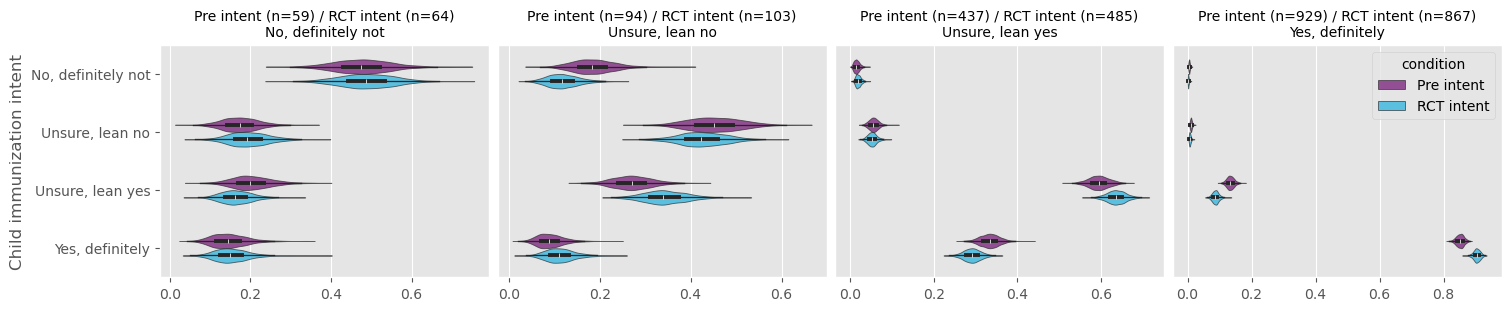

In [19]:
_results_dict = results_dict['average_post'] # ['average_post'] + [0,1,2,3,4,5,6]

plt.style.use('ggplot')
N_dep = 4

legend_labels = {
            3: '99.5% of posterior of poststratified difference in probabilities above 0',
            2: '95% of posterior of poststratified difference in probabilities above 0',
            1: '90% of posterior of poststratified difference in probabilities above 0',
            0: 'At least 10% of posterior of poststratified difference in probabilities below and 10% above 0',
            -1: '90% of posterior of poststratified difference in probabilities below 0',
            -2: '95% of posterior of poststratified difference in probabilities below 0',
            -3: '99.5% of posterior of poststratified difference in probabilities below 0',}


recode_rct_for_plot = {0 : 'No, definitely not', 1 :'Unsure, lean no', 2:'Unsure, lean yes', 3 : 'Yes, definitely'}

fig, axes = plt.subplots( 1, N_dep, figsize = (15,3), constrained_layout = True)

def get_color(df,c):
    perc = 0.1 * 50
    if ( np.percentile(df[c], 10) > 0 ) and (np.percentile(df[c], 5) <= 0):
        return(palette[1])
    elif ( np.percentile(df[c], 5) > 0 ) and (np.percentile(df[c], 0.5) <= 0):
        return(palette[2])
    elif (np.percentile(df[c], 0.5) > 0):
        return(palette[3])
        
    elif (np.percentile(df[c], 90) < 0) and (np.percentile(df[c], 95) >= 0):
        return(palette[-1])
    elif (np.percentile(df[c], 95) < 0) and (np.percentile(df[c], 99.5) >= 0):
        return(palette[-2])
    elif (np.percentile(df[c], 99.5) < 0):
        return(palette[-3])
    else:
        return(palette[0])

c1, c2, c3 = 'black', 'purple', 'deepskyblue'

for y_post in range(N_dep):
    ax = axes[y_post]
    df_post = pd.DataFrame( _results_dict['y_prob_child_cond_on_post'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_pre = pd.DataFrame( _results_dict['y_prob_child_cond_on_pre'][:,y_post, :], columns = recode_rct_for_plot.values() )

    df_post['condition'] = 'RCT intent'
    df_pre['condition'] = 'Pre intent'
    combined_df = pd.concat([df_pre, df_post], axis = 0)
    melted_df = pd.melt(combined_df, id_vars=['condition'], 
                     value_vars=['No, definitely not','Unsure, lean no','Unsure, lean yes','Yes, definitely'],
                     var_name='Response', value_name='Value')
    if y_post == 3:
        sns.violinplot(y='Response', x='Value', hue='condition', data=melted_df, palette={'Pre intent': 'purple', 'RCT intent': 'deepskyblue'},
                   legend = True, ax = ax, orient = 'h', width = 0.5, density_norm = 'width', alpha = 0.7)
    else:
        sns.violinplot(y='Response', x='Value', hue='condition', data=melted_df, palette={'Pre intent': 'purple', 'RCT intent': 'deepskyblue'},
                   legend = False, ax = ax, orient = 'h', width = 0.5, density_norm = 'width', alpha = 0.7)
    if y_post == 0:
        # ax.set_ylabel(f'RCT {t} (RCT {control})')
        ax.set_ylabel(f'Child immunization intent')
    else:
        ax.set_ylabel('')
    ax.set_xlabel('')
    if y_post != 0:
        ax.set_yticklabels([])
        ax.tick_params(axis='y', which='both', length=0) 
        # if j == 0:
    _intent = list( recode_mapping_for_plot['rsv_intent_hyp_pre'].values() )[y_post]
    n_pre = survey_for_plot[survey_for_plot['rsv_intent_hyp_pre'] == _intent].shape[0]
    n_post = survey_for_plot[survey_for_plot['rsv_intent_hyp_post'] == _intent].shape[0]
    
    ax.set_title(f'Pre intent (n={n_pre}) / RCT intent (n={n_post})\n{list(recode_rct_for_plot.values())[y_post]}', size= 10)


# fig.savefig('./fig/uk/rsv_intent_causal_child_probs.jpg', dpi = 200, bbox_inches='tight')


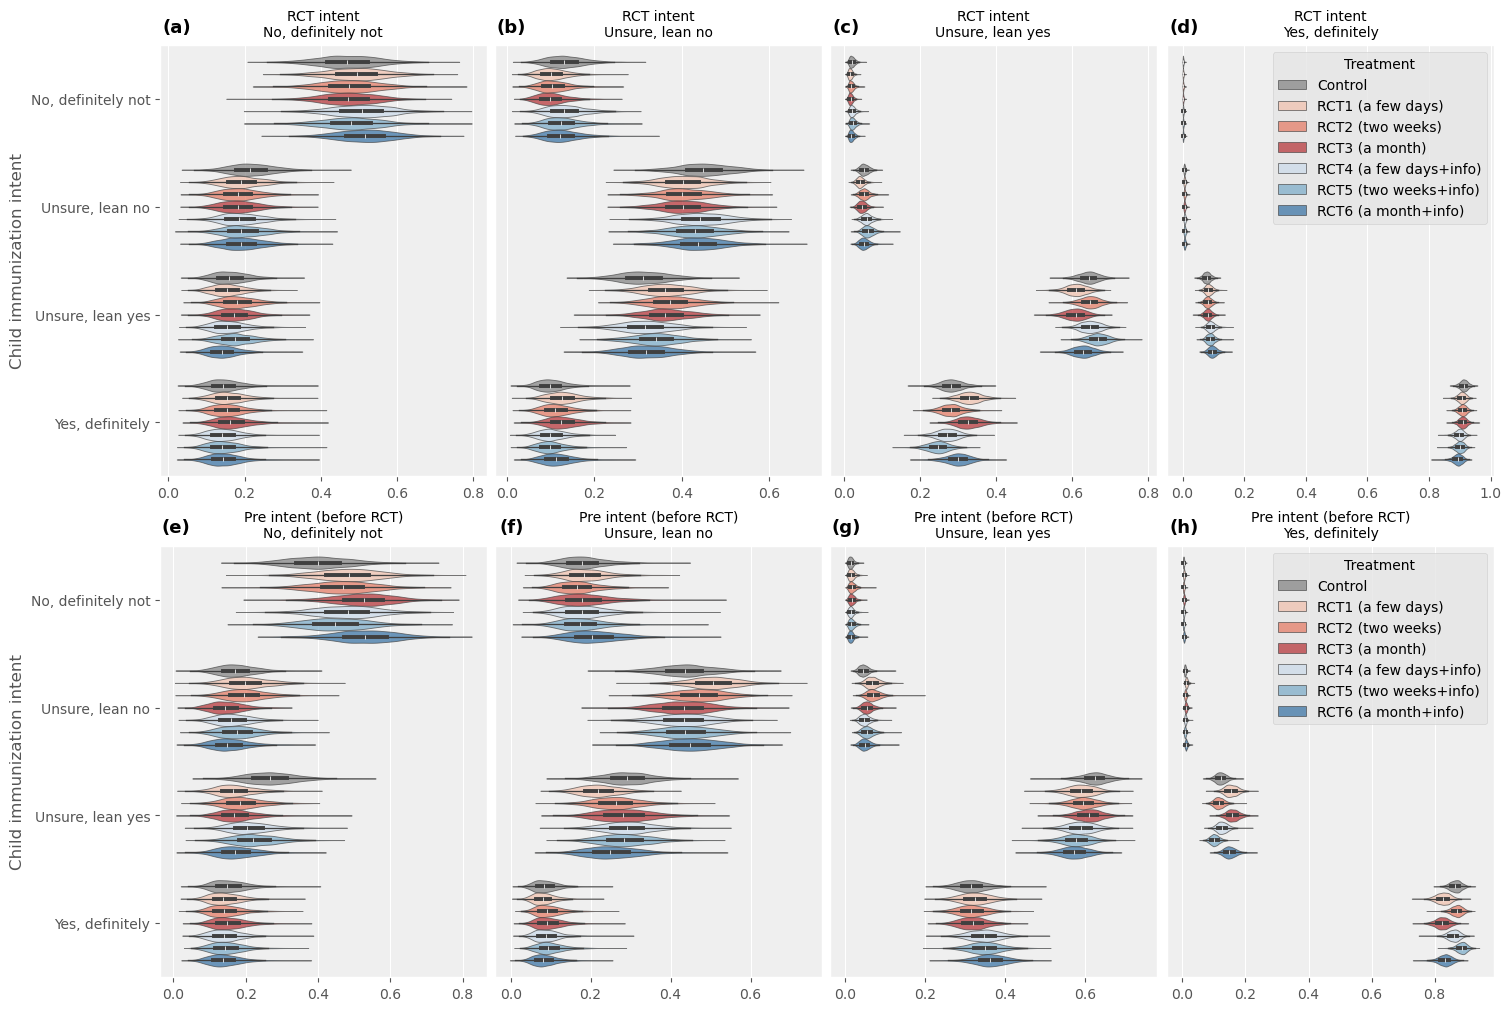

In [20]:
_results_dict = results_dict['average_post'] # ['average_post'] + [0,1,2,3,4,5,6]

plt.style.use('ggplot')
N_dep = 4

recode_rct_for_plot = {0 : 'No, definitely not', 1 :'Unsure, lean no', 2:'Unsure, lean yes', 3 : 'Yes, definitely'}

fig, axes = plt.subplots( 2, N_dep, figsize = (15,10), constrained_layout = True)

c1, c2, c3 = 'black', 'purple', 'deepskyblue'

for y_post, plot_label in zip(range(N_dep),['(a)','(b)','(c)','(d)']):
    ax = axes[0,y_post]
    df_0 = pd.DataFrame( results_dict[0]['y_prob_child_cond_on_post'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_1 = pd.DataFrame( results_dict[1]['y_prob_child_cond_on_post'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_2 = pd.DataFrame( results_dict[2]['y_prob_child_cond_on_post'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_3 = pd.DataFrame( results_dict[3]['y_prob_child_cond_on_post'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_4 = pd.DataFrame( results_dict[4]['y_prob_child_cond_on_post'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_5 = pd.DataFrame( results_dict[5]['y_prob_child_cond_on_post'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_6 = pd.DataFrame( results_dict[6]['y_prob_child_cond_on_post'][:,y_post, :], columns = recode_rct_for_plot.values() )
    
    df_0['Treatment'] = 'Control'
    df_1['Treatment'] = 'RCT1 (a few days)'
    df_2['Treatment'] = 'RCT2 (two weeks)'
    df_3['Treatment'] = 'RCT3 (a month)'
    df_4['Treatment'] = 'RCT4 (a few days+info)'
    df_5['Treatment'] = 'RCT5 (two weeks+info)'
    df_6['Treatment'] = 'RCT6 (a month+info)'
    combined_df = pd.concat([df_0, df_1, df_2, df_3, df_4, df_5, df_6], axis = 0)
    melted_df = pd.melt(combined_df, id_vars=['Treatment'], 
                     value_vars=['No, definitely not','Unsure, lean no','Unsure, lean yes','Yes, definitely'],
                     var_name='Response', value_name='Value')
    my_pal_blues = sns.color_palette("Blues", n_colors=3)
    my_pal_reds = sns.color_palette("Reds", n_colors=3)

    timings = ['a few days', 'two weeks', 'a month']
    my_pal = {f'RCT{i} ({timings[i-1]})' : my_pal_reds[i-1] for i in range(1,4)}
    my_pal_update = {f'RCT{i} ({timings[i-4]}+info)' : my_pal_blues[i-4] for i in range(4,7)}
    my_pal.update(my_pal_update)
    my_pal['Control'] = 'grey'
    
    if y_post == 3:
        sns.violinplot(y='Response', x='Value', hue='Treatment', data=melted_df, palette=my_pal,
                   legend = True, ax = ax, orient = 'h', width = 0.8, density_norm = 'width', alpha = 0.7)
    else:
        sns.violinplot(y='Response', x='Value', hue='Treatment', data=melted_df, palette=my_pal,
                   legend = False, ax = ax, orient = 'h', width = 0.8, density_norm = 'width', alpha = 0.7)
    if y_post == 0:
        ax.set_ylabel(f'Child immunization intent')
    else:
        ax.set_ylabel('')
    ax.set_xlabel('')
    if y_post != 0:
        ax.set_yticklabels([])
        ax.tick_params(axis='y', which='both', length=0) 
        # if j == 0:
    _intent = list( recode_mapping_for_plot['rsv_intent_hyp_pre'].values() )[y_post]
    n_pre = survey_for_plot[survey_for_plot['rsv_intent_hyp_pre'] == _intent].shape[0]
    n_post = survey_for_plot[survey_for_plot['rsv_intent_hyp_post'] == _intent].shape[0]
    ax.set_title(f'RCT intent\n{list(recode_rct_for_plot.values())[y_post]}', size= 10)
    ax.text(0.05, 1.03, plot_label, transform=ax.transAxes, fontsize=13, fontweight='bold', ha='center')
    ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )
for y_post, plot_label in zip(range(N_dep), ['(e)','(f)','(g)','(h)']):
    ax = axes[1,y_post]
    df_0 = pd.DataFrame( results_dict[0]['y_prob_child_cond_on_pre'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_1 = pd.DataFrame( results_dict[1]['y_prob_child_cond_on_pre'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_2 = pd.DataFrame( results_dict[2]['y_prob_child_cond_on_pre'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_3 = pd.DataFrame( results_dict[3]['y_prob_child_cond_on_pre'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_4 = pd.DataFrame( results_dict[4]['y_prob_child_cond_on_pre'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_5 = pd.DataFrame( results_dict[5]['y_prob_child_cond_on_pre'][:,y_post, :], columns = recode_rct_for_plot.values() )
    df_6 = pd.DataFrame( results_dict[6]['y_prob_child_cond_on_pre'][:,y_post, :], columns = recode_rct_for_plot.values() )

    
    df_0['Treatment'] = 'Control'
    df_1['Treatment'] = 'RCT1 (a few days)'
    df_2['Treatment'] = 'RCT2 (two weeks)'
    df_3['Treatment'] = 'RCT3 (a month)'
    df_4['Treatment'] = 'RCT4 (a few days+info)'
    df_5['Treatment'] = 'RCT5 (two weeks+info)'
    df_6['Treatment'] = 'RCT6 (a month+info)'
    combined_df = pd.concat([df_0, df_1, df_2, df_3, df_4, df_5, df_6], axis = 0)
    melted_df = pd.melt(combined_df, id_vars=['Treatment'], 
                     value_vars=['No, definitely not','Unsure, lean no','Unsure, lean yes','Yes, definitely'],
                     var_name='Response', value_name='Value')
    my_pal_blues = sns.color_palette("Blues", n_colors=3)
    my_pal_reds = sns.color_palette("Reds", n_colors=3)
    timings = ['a few days', 'two weeks', 'a month']
    my_pal = {f'RCT{i} ({timings[i-1]})' : my_pal_reds[i-1] for i in range(1,4)}
    my_pal_update = {f'RCT{i} ({timings[i-4]}+info)' : my_pal_blues[i-4] for i in range(4,7)}
    my_pal.update(my_pal_update)
    my_pal['Control'] = 'grey'
    
    if y_post == 3:
        sns.violinplot(y='Response', x='Value', hue='Treatment', data=melted_df, palette=my_pal,
                   legend = True, ax = ax, orient = 'h', width = 0.8, density_norm = 'width', alpha = 0.7)
    else:
        sns.violinplot(y='Response', x='Value', hue='Treatment', data=melted_df, palette=my_pal,
                   legend = False, ax = ax, orient = 'h', width = 0.8, density_norm = 'width', alpha = 0.7)
    if y_post == 0:
        ax.set_ylabel(f'Child immunization intent')
    else:
        ax.set_ylabel('')
    ax.set_xlabel('')
    if y_post != 0:
        ax.set_yticklabels([])
        ax.tick_params(axis='y', which='both', length=0) 
    _intent = list( recode_mapping_for_plot['rsv_intent_hyp_pre'].values() )[y_post]
    n_pre = survey_for_plot[survey_for_plot['rsv_intent_hyp_pre'] == _intent].shape[0]
    n_post = survey_for_plot[survey_for_plot['rsv_intent_hyp_post'] == _intent].shape[0]

    ax.set_title(f'Pre intent (before RCT)\n{list(recode_rct_for_plot.values())[y_post]}', size= 10)
    ax.text(0.05, 1.03, plot_label, transform=ax.transAxes, fontsize=13, fontweight='bold', ha='center')
    ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )

fig.savefig('./fig/uk/rsv_intent_child_probs_cond_on_treat.jpg', dpi = 200, bbox_inches='tight')


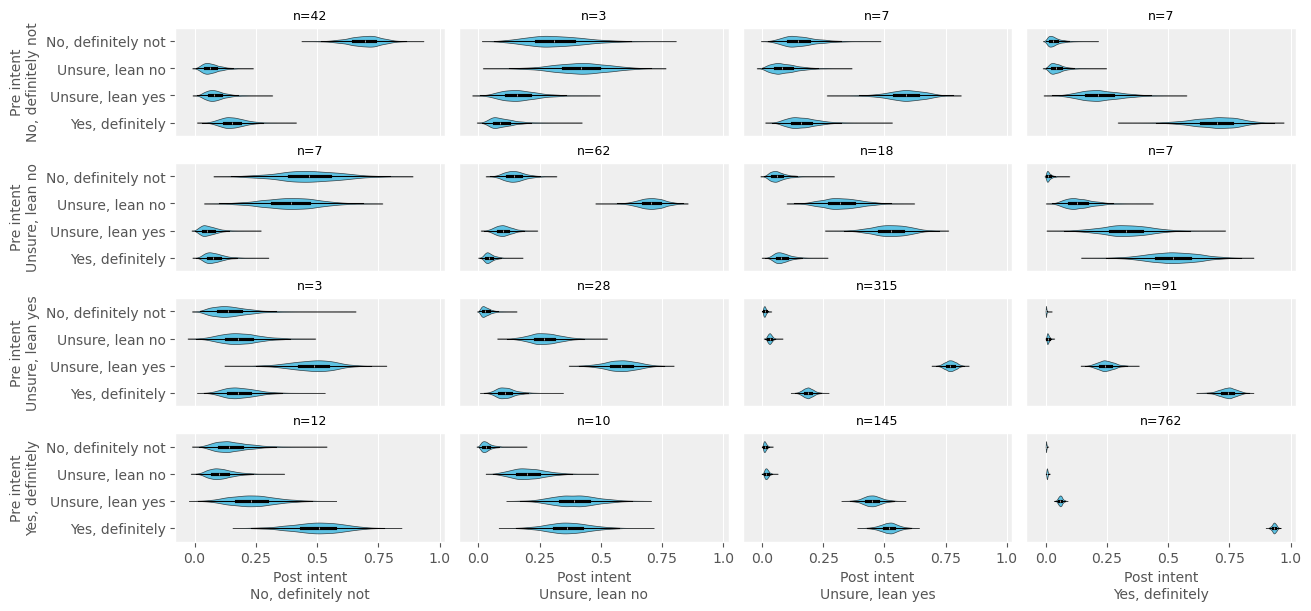

In [21]:
_results_dict = results_dict['average_post'] # ['average_post'] + [0,1,2,3,4,5,6]

plt.style.use('ggplot')
N_dep = 4

recode_rct_for_plot = {0 : 'No, definitely not', 1 :'Unsure, lean no', 2:'Unsure, lean yes', 3 : 'Yes, definitely'}

fig, axes = plt.subplots( N_dep, N_dep, figsize = (13,6), constrained_layout = True, sharex = True)


c1, c2, c3 = 'black', 'purple', 'deepskyblue'

for y_pre in range(N_dep):
    for y_post in range(N_dep):
        ax = axes[y_pre, y_post]
        df = pd.DataFrame( _results_dict['y_prob_child_cond_on_pre_post'][:, y_pre, y_post, :], columns = recode_rct_for_plot.values() )
        sns.violinplot(df, legend = False, ax = ax, orient = 'h', width = 0.4, density_norm = 'width', alpha = 0.7, linewidth=0.5, linecolor='black', inner= 'box',# color = 'purple')
                        color = 'deepskyblue')

for y_pre in range(N_dep):
    for y_post in range(N_dep):
        ax = axes[y_pre, y_post]
        if y_post != 0:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', which='both', length=0) 
        if y_pre < 3:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', which='both', length=0) 
        else:
            ax.set_xticks([0.0,0.25,0.5,0.75,1.0])
            ax.set_xticklabels([0.0,0.25,0.5,0.75,1.0])

        if y_post == 0:
            _label = f'Pre intent\n{list(recode_rct_for_plot.values())[y_pre]}'
            ax.set_ylabel(_label, size = 10)
        if y_pre == 3:
            _label = f'Post intent\n{list(recode_rct_for_plot.values())[y_post]}'
            ax.set_xlabel(_label, size = 10)


        _intent_pre = list( recode_mapping_for_plot['rsv_intent_hyp_pre'].values() )[y_pre]
        _intent_post = list( recode_mapping_for_plot['rsv_intent_hyp_pre'].values() )[y_post]
        _num_cases = survey_for_plot[ (survey_for_plot['rsv_intent_hyp_pre'] == _intent_pre) &  (survey_for_plot['rsv_intent_hyp_post'] == _intent_post) ].shape[0] 
        _title = f'n={_num_cases}'
        ax.set_title(_title, size = 9)

        ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )
# fig.savefig('./fig/uk/rsv_intent_causal_child_probs_pre_post_joint.jpg', dpi = 200, bbox_inches='tight')


In [23]:
def plot_odds_ratio(idata, ax, recode_mapping_reverse,  coef_name, var_name, baseline, survey = None, add_n = False, title = None, num_samples = 2000, max_len_label = 10, plot_type = 'boxplot',
                    violin_width = None, odds_ratio = True, palette = None, alpha = 1, orderd_labels_dict = {}, title_size = None, ext1 = 'child', ext2 = 'post' ):
    if palette is None:
        palette = {
            3: sns.color_palette("Blues", n_colors=8)[6],  # High Positive (Dark Blue)
            2: sns.color_palette("Blues", n_colors=8)[4],  # Medium Positive (Medium Blue)
            1: sns.color_palette("Blues", n_colors=8)[2],  # Low Positive (Light Blue)
            0 : sns.color_palette("Grays", n_colors=7)[2],
            -1: sns.color_palette("Reds", n_colors=8)[2],  # Low Negative (Light Red)
            -2: sns.color_palette("Reds", n_colors=8)[4],  # Medium Negative
            -3: sns.color_palette("Reds", n_colors=8)[6],  # High Negative (Dark Red)
        }

    if add_n and survey is None:
        raise ValueError('must provide survey when add_n = True')
    def get_color(df,c):
        perc = 0.1 * 50
        if ( np.percentile(df[c], 10) > 0 ) and (np.percentile(df[c], 5) <= 0):
            return(palette[1])
        elif ( np.percentile(df[c], 5) > 0 ) and (np.percentile(df[c], 0.5) <= 0):
            return(palette[2])
        elif (np.percentile(df[c], 0.5) > 0):
            return(palette[3])
            
        elif (np.percentile(df[c], 90) < 0) and (np.percentile(df[c], 95) >= 0):
            return(palette[-1])
        elif (np.percentile(df[c], 95) < 0) and (np.percentile(df[c], 99.5) >= 0):
            return(palette[-2])
        elif (np.percentile(df[c], 99.5) < 0):
            return(palette[-3])
        else:
            return(palette[0])
    _post = idata.posterior[coef_name].values.reshape(num_samples,-1)
    
    if _post.shape[1] == 1:
        _post = np.hstack([_post, -_post])
    _df = pd.DataFrame(_post, columns = recode_mapping_reverse[var_name].values() )

    if var_name in orderd_labels_dict:
        orderd_labels = orderd_labels_dict[var_name]
        _df = _df[orderd_labels]
        

    original_columns = _df.columns
    truncated_columns = [col[:max_len_label] for k,col in enumerate(_df.columns)]
    if len(set(original_columns)) != len(set(truncated_columns)):
        truncated_columns = [col[:max_len_label] + f' c{k}' for k,col in enumerate(_df.columns)]
    _df.columns = truncated_columns

    _df = _df.drop(columns = [baseline]) - np.array(_df[baseline])[:, None]

    
    my_pal = {c : get_color(_df,c) for c in _df.columns}
    
    _df = np.exp(_df)
    if plot_type == 'boxplot':
        sns.boxplot(data = _df, orient="h", ax = ax, palette=my_pal)
    elif plot_type == 'violin':
        if violin_width is None:
            sns.violinplot(data=_df, orient="h", ax=ax, palette=my_pal, linewidth=0.5, linecolor='black', inner= 'box', alpha = alpha)# inner one of: 'box', 'stick', 'point', None
        else:
            sns.violinplot(data=_df, orient="h", ax=ax, palette=my_pal, linewidth=0.5, linecolor='black', inner= 'box', density_norm='area', width=violin_width, alpha = alpha)
        
    else:
        raise ValueError('non valid plot_type')

    if add_n:
        num_n = dict( survey[var_name].value_counts() )
        num_n = {k : f'n={v}' for k,v in num_n.items()}
        ax2 = ax.twinx()
        ax2.set_ylim(ax.get_ylim())
        ax2.set_yticks(ax.get_yticks())
        ax2.set_yticklabels([num_n[col] for col in _df.columns])
        ax2.grid(False) 

        
        ax2.tick_params(length=0)

    if odds_ratio:
        ax.axvline(x = 1, c = 'dimgray', linewidth = 2, zorder = 0)
    else:    
        ax.axvline(x = 0, c = 'dimgray', linewidth = 2, zorder = 0)
    if title is not None:
        if add_n:
            title = f'{title} ({num_n[baseline]})'
        if title_size:
            ax.set_title(title, size = title_size)
        else:
            ax.set_title(title)

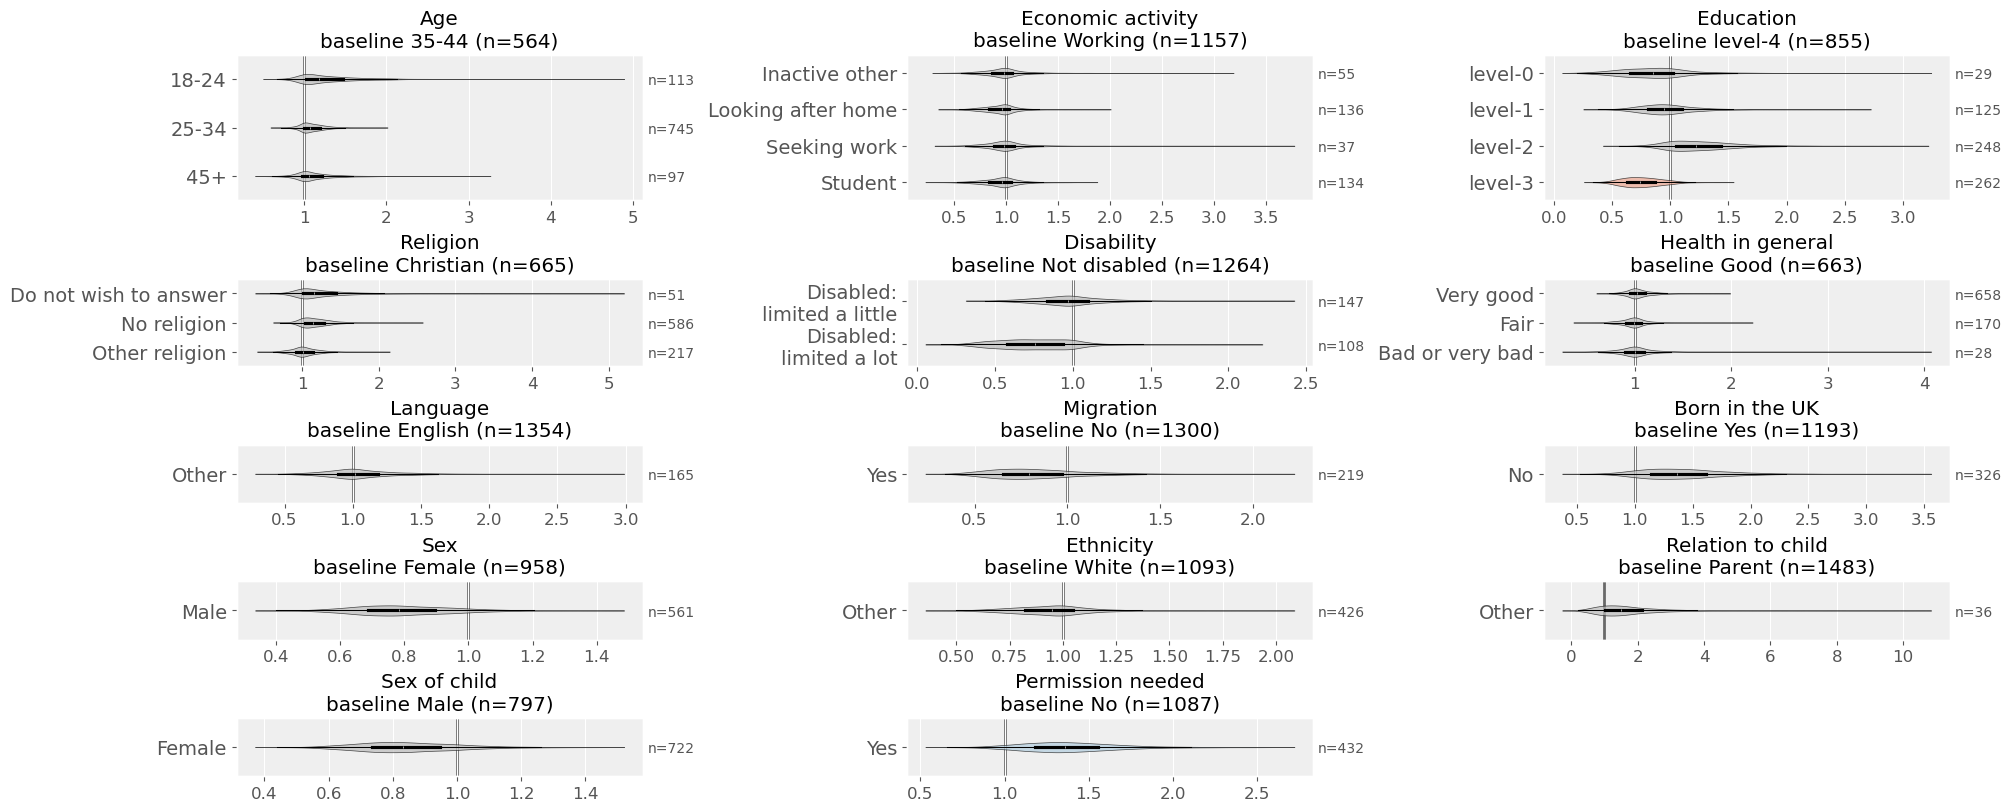

In [24]:
title_var_names = {'AGE': 'Age',
 'SEX': 'Sex',
 'EDU': 'Education',
 'REL': 'Religion',
 'ETH': 'Ethnicity',
 'LAN': 'Language',
 'HHLAN': 'Household language English',
 'MIG': 'Migration',
 'BUK': 'Born in the UK',
 'YUK': 'Year of arrival in UK',
 'HEA': 'Health in general',#'Fair',
 'SCH': 'No',
 'DIS': 'Disability',
 'ENP': 'Enlgish proficieny',
 'EMP': 'Economic activity',
 'X1_relationship_ch_i' : 'Relation to child',
 'X1_sex_ch_i' : 'Sex of child',
 'X1_permission_ch_i' : 'Permission needed'}

baselines = {'AGE': '35-44', # '18-24',
 'SEX': 'Female',
 'EDU': 'level-4',
 'REL': 'Christian',
 'ETH': 'White',
 'LAN': 'English',
 'MIG': 'No',
 'BUK': 'Yes',
 'ENP': 'Very well or well',
 'DIS' : 'Not disabled',
 'HEA': 'Good', #'Fair',
 'EMP': 'Working',
 'SCH': 'No',
 'X1_relationship_ch_i' : 'Parent',
 'X1_sex_ch_i' : 'Male',
 'X1_permission_ch_i' : 'No',
}

plt.style.use('ggplot')


orderd_labels_dict = {}
for var_name in ['ETH','REL','LAN','EMP','EDU','AGE']:
    orderd_labels_dict[var_name] = list( np.sort( list( recode_mapping_for_plot[var_name].values() ) ) )

orderd_labels_dict['HEA'] = ['Very good', 'Good', 'Fair', 'Bad or very bad']
orderd_labels_dict['DIS'] = ['Not disabled', 'Disabled:\nlimited a little', 'Disabled:\nlimited a lot']

height_ratios = [5, 3, 2, 2, 2]

fig, axes = plt.subplots(5,3, figsize = (20,8), constrained_layout = True, height_ratios = height_ratios )
for k, (var_name, coef_name) in enumerate( zip(['AGE','EMP', 'EDU','REL','DIS','HEA','LAN','MIG','BUK','SEX','ETH'] + ['X1_relationship_ch_i','X1_sex_ch_i', 'X1_permission_ch_i'], #, 'SCH'],
                                              ['beta_age_child', 'beta_emp_child', 'beta_edu_child', 'beta_rel_child', 'beta_dis_child', 'beta_hea_child', 'beta_lan_child', 'beta_mig_child', 'beta_buk_child',
                                               'beta_sex_child', 'beta_eth_child'] + ['beta_rel_ch_i_child','beta_sex_ch_i_child','beta_per_ch_i_child']) #, 'beta_sch'])
                                         ):
    i,j = k //3, k%3
    ax = axes[i,j]
    h_ratio = height_ratios[i]
    num_violin_plots = len(recode_mapping_reverse[var_name].values()) - 1
    _title = f'{title_var_names[var_name]}\nbaseline {baselines[var_name]}'
    plot_odds_ratio(idata = idata, ax = ax, recode_mapping_reverse = recode_mapping_for_plot, coef_name = coef_name, var_name = var_name, title =_title, num_samples = 2000, 
                    plot_type = 'violin', violin_width = 0.35*(num_violin_plots/h_ratio), max_len_label = 30, baseline = baselines[var_name], survey = survey_for_plot, add_n = True,#  palette = palette,
                    alpha = alpha_violin_plot_soc, orderd_labels_dict = orderd_labels_dict )
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=12)

    ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )

axes[4,2].remove()

# fig.savefig('./fig/uk/rsv_intent_causal_child_odds_ratios.jpg', dpi = 200, bbox_inches='tight')